Q1. Load load_breast_cancer() built in dataset.

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
breast_cancer_data = load_breast_cancer()
print(breast_cancer_data)

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]]), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
 

In [2]:
X = breast_cancer_data.data
y = breast_cancer_data.target
feature_names = breast_cancer_data.feature_names
print(feature_names)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


Q2. convert dataset to pandas dataframe.

In [3]:
df_features = pd.DataFrame(X, columns=feature_names)
print(df_features.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

Q3. Append dataframe containing tumor features with diagnostic outcomes.

In [4]:
df_target = pd.Series(y, name='diagnosis')
df = pd.concat([df_features, df_target], axis=1)
print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

Q4.Find relation in diagnosis by using mean.

In [5]:
mean_features = df.groupby('diagnosis').mean()
print(mean_features)

           mean radius  mean texture  mean perimeter   mean area  \
diagnosis                                                          
0            17.462830     21.604906      115.365377  978.376415   
1            12.146524     17.914762       78.075406  462.790196   

           mean smoothness  mean compactness  mean concavity  \
diagnosis                                                      
0                 0.102898          0.145188        0.160775   
1                 0.092478          0.080085        0.046058   

           mean concave points  mean symmetry  mean fractal dimension  ...  \
diagnosis                                                              ...   
0                     0.087990       0.192909                0.062680  ...   
1                     0.025717       0.174186                0.062867  ...   

           worst radius  worst texture  worst perimeter   worst area  \
diagnosis                                                              
0            

Q5. create to dataframes - one for positive, one for negative(diagnosis).

In [6]:
df_positive = df[df['diagnosis'] == 1]
df_negative = df[df['diagnosis'] == 0]
print("Positive diagnosis (Malignant):")
print(df_positive.head())
print("\nNegative diagnosis (Benign):")
print(df_negative.head())

Positive diagnosis (Malignant):
    mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
19       13.540         14.36           87.46      566.3          0.09779   
20       13.080         15.71           85.63      520.0          0.10750   
21        9.504         12.44           60.34      273.9          0.10240   
37       13.030         18.42           82.61      523.8          0.08983   
46        8.196         16.84           51.71      201.9          0.08600   

    mean compactness  mean concavity  mean concave points  mean symmetry  \
19           0.08129         0.06664             0.047810         0.1885   
20           0.12700         0.04568             0.031100         0.1967   
21           0.06492         0.02956             0.020760         0.1815   
37           0.03766         0.02562             0.029230         0.1467   
46           0.05943         0.01588             0.005917         0.1769   

    mean fractal dimension  ...  worst texture  

Q6. Visualize tumor characteristics for positive and negatives diagnoses

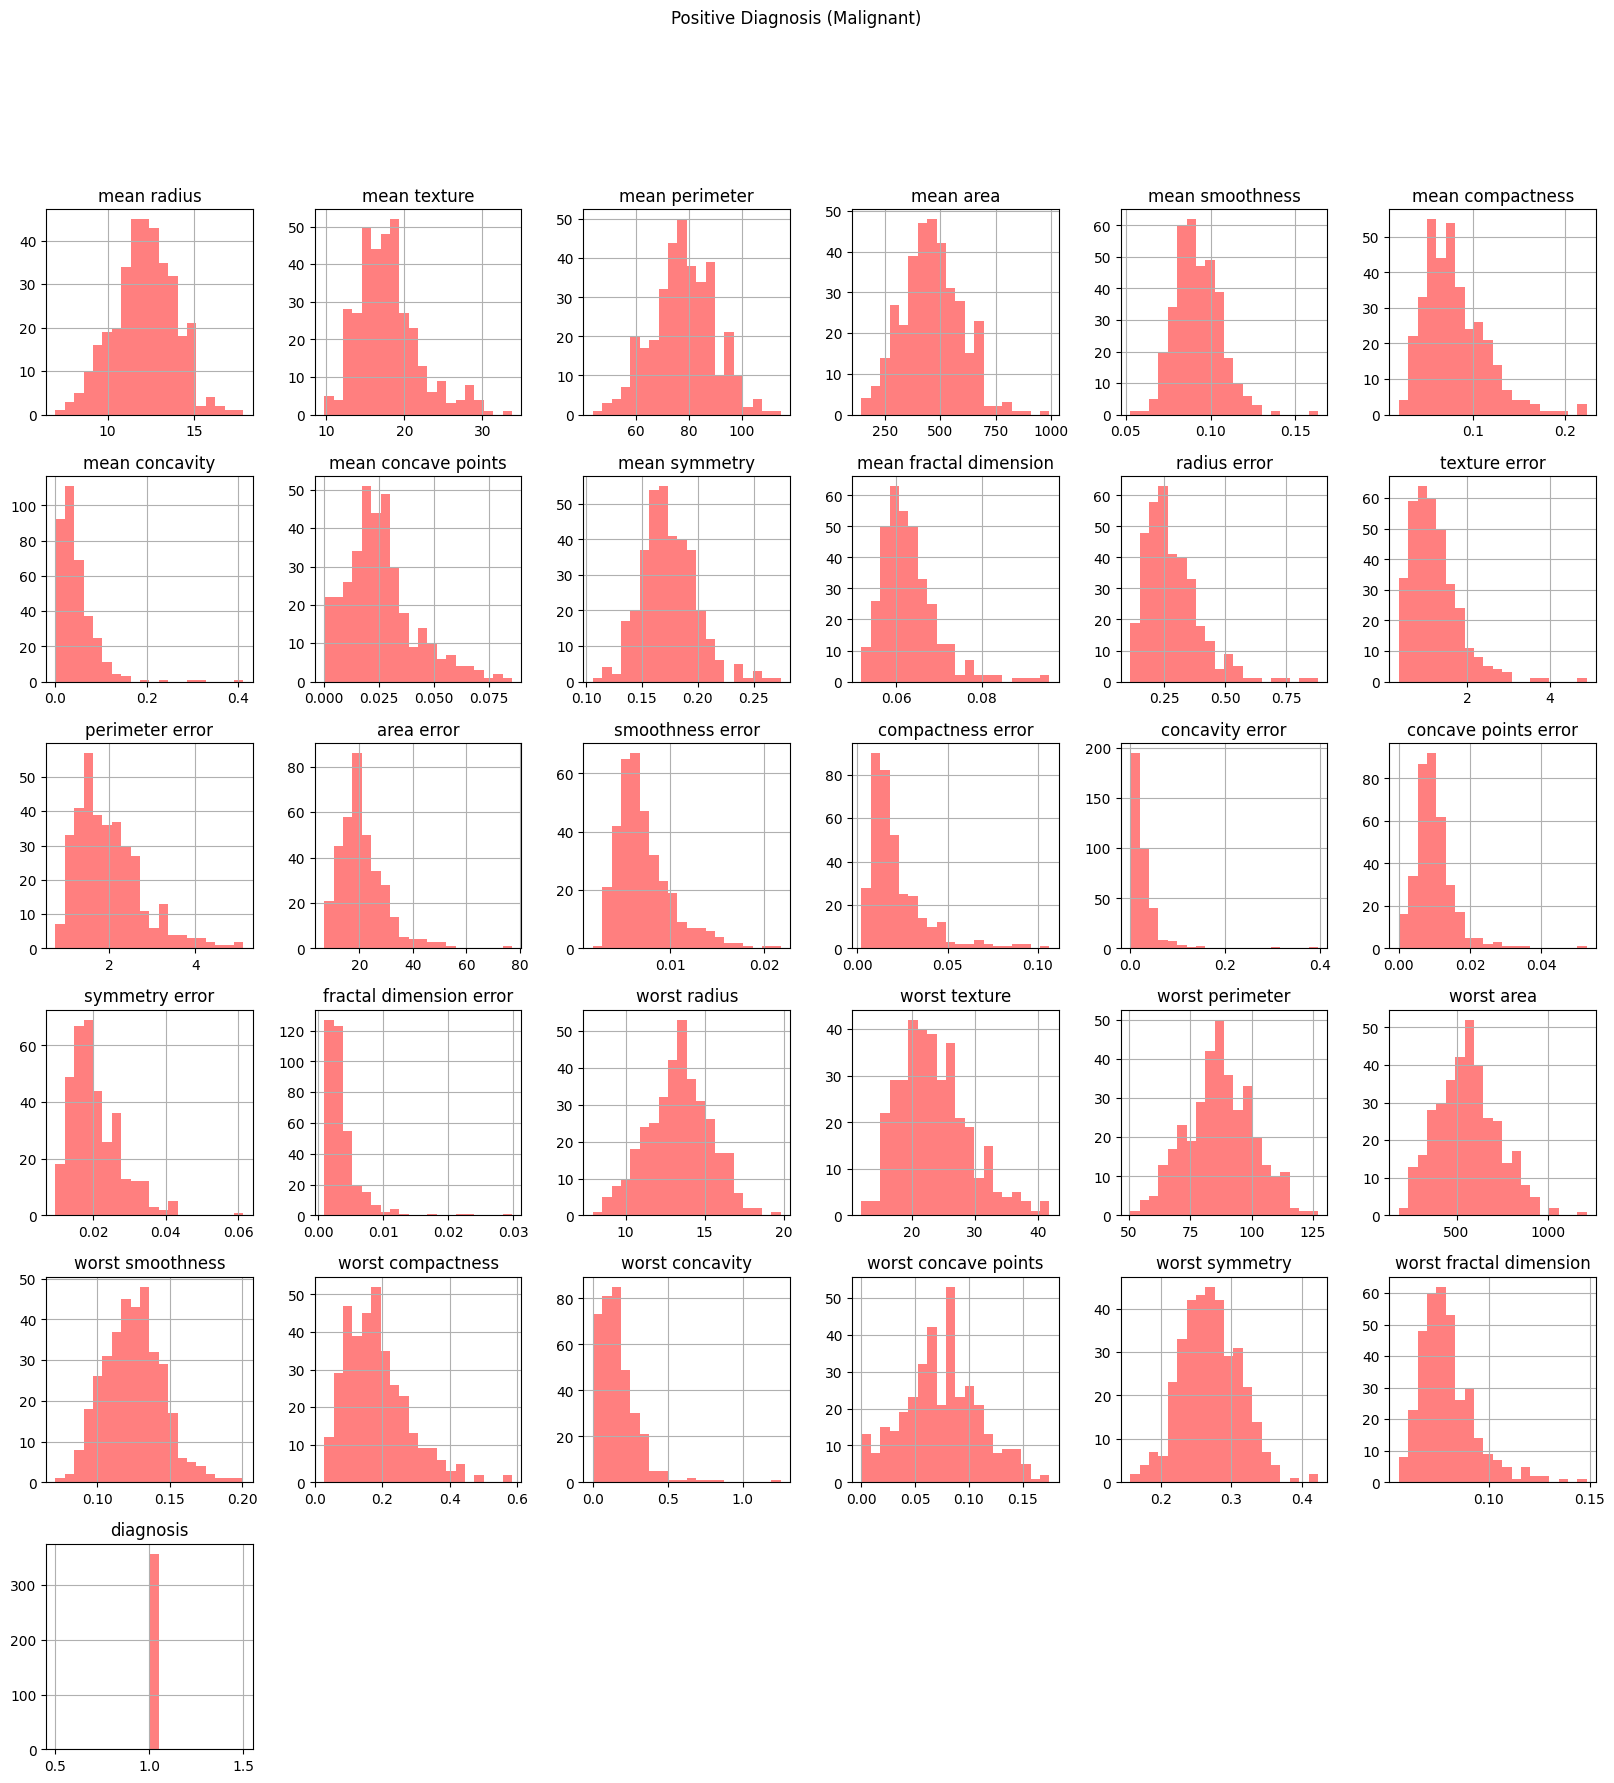

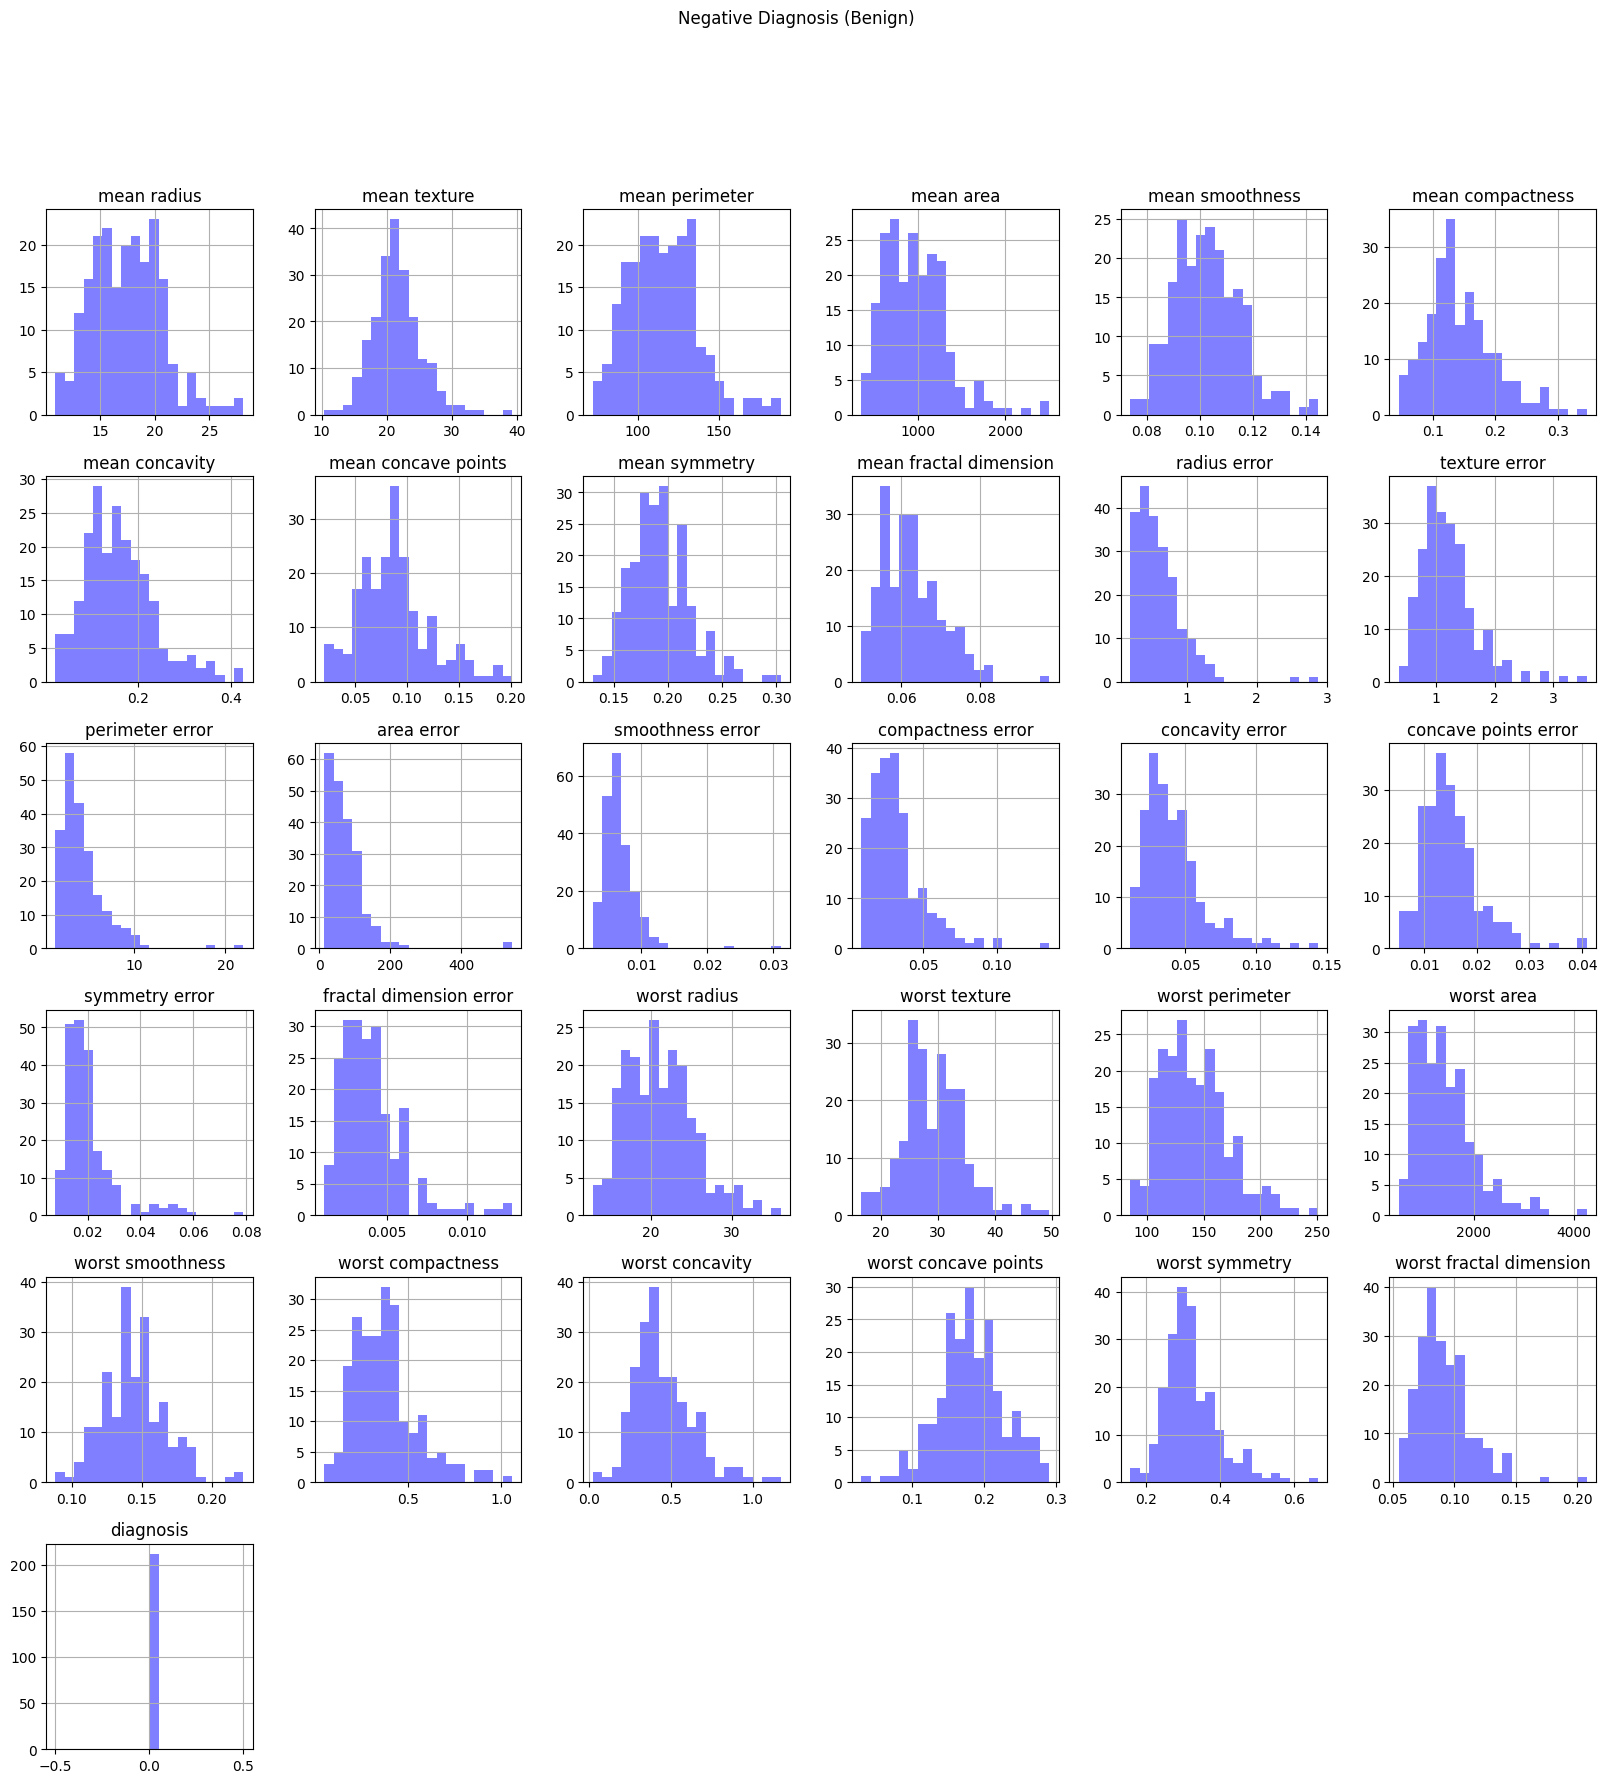

In [7]:
import matplotlib.pyplot as plt
df_positive.hist(figsize=(20, 20), bins=20, color='red', alpha=0.5)
plt.suptitle('Positive Diagnosis (Malignant)')
plt.show()
df_negative.hist(figsize=(20, 20), bins=20, color='blue', alpha=0.5)
plt.suptitle('Negative Diagnosis (Benign)')
plt.show()

Q7. Create 'for loop' to enerate though tumor features and compare with histograms(20:-1)

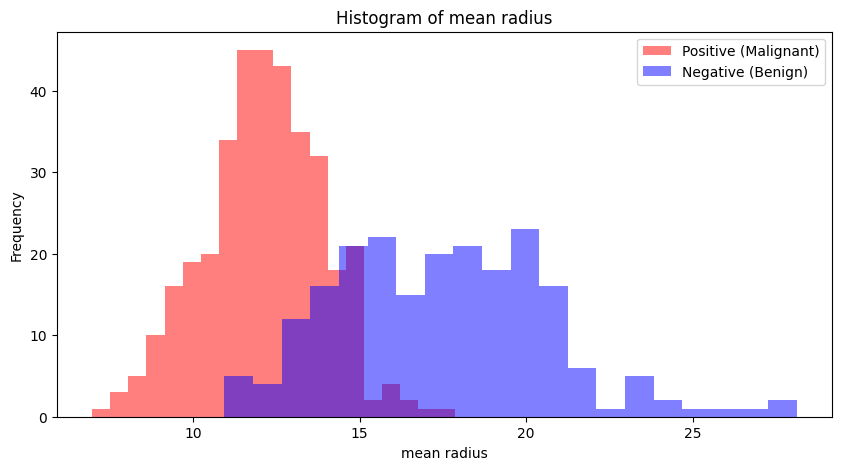

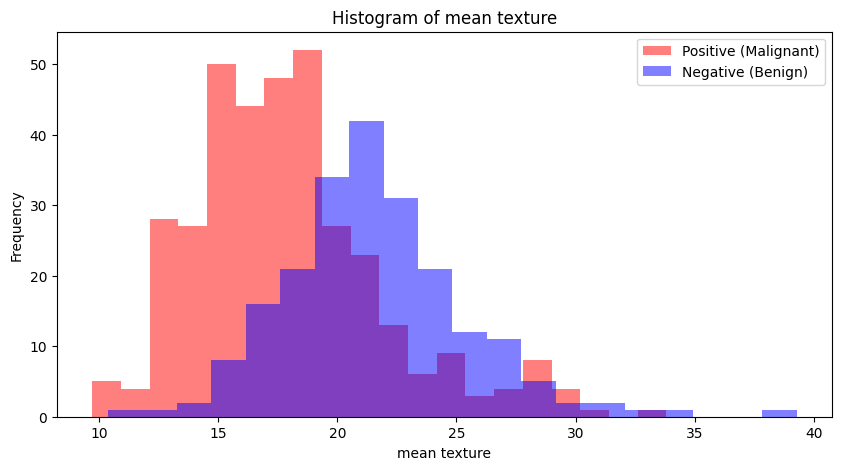

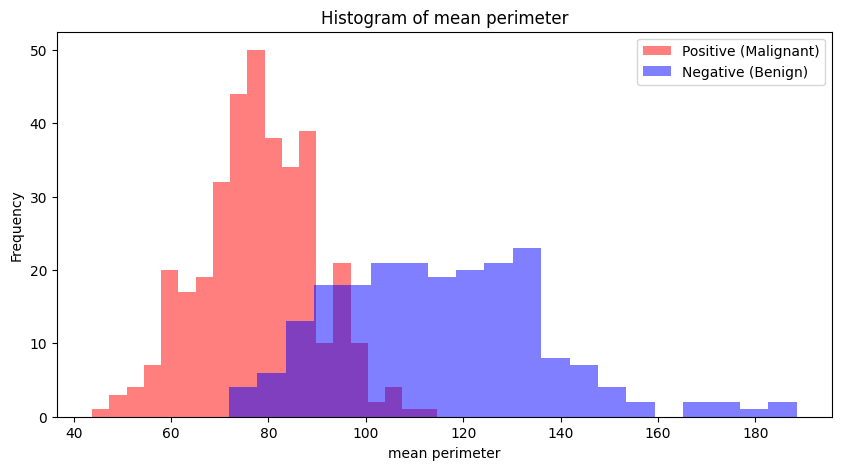

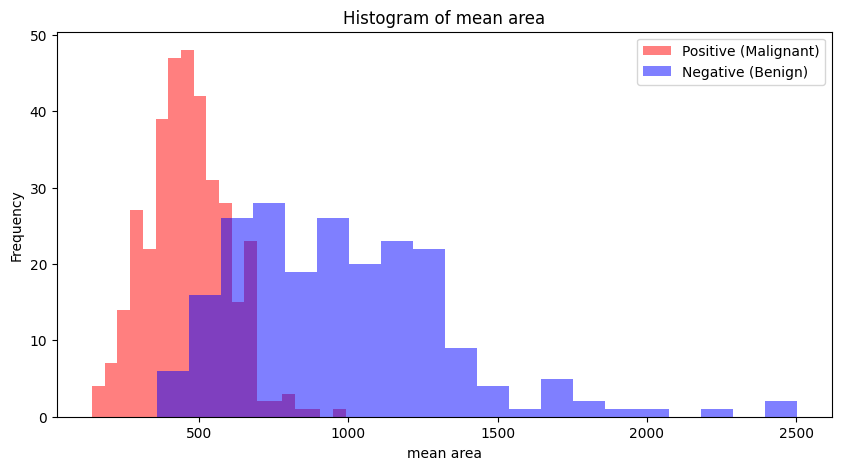

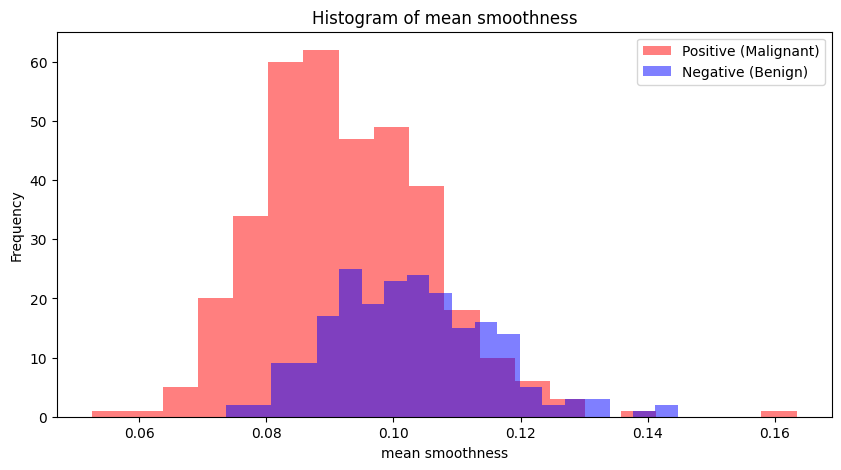

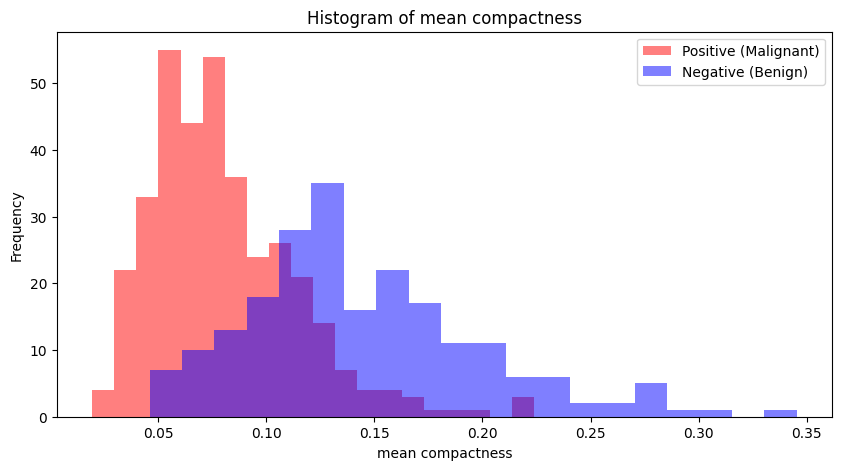

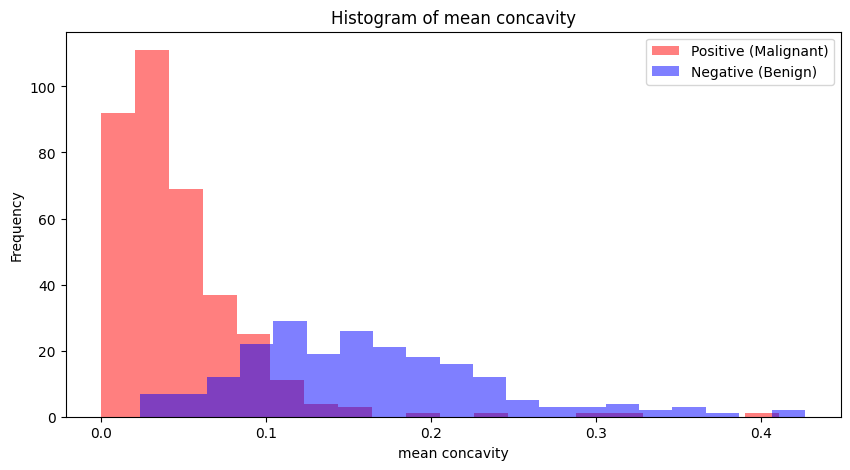

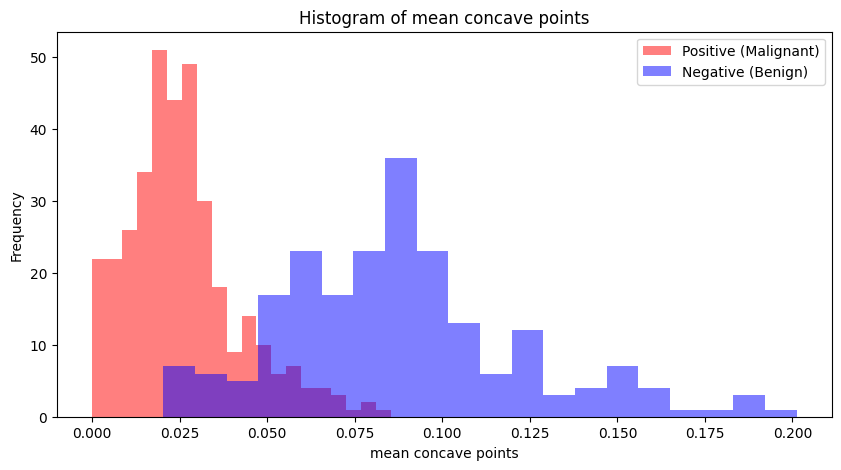

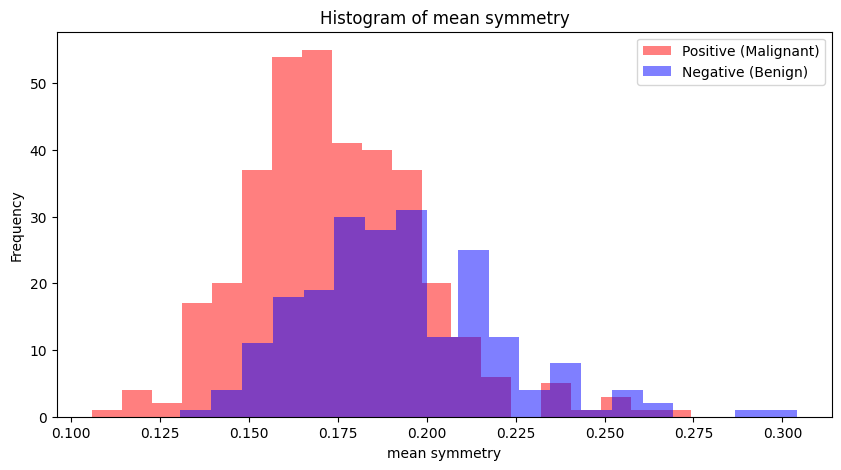

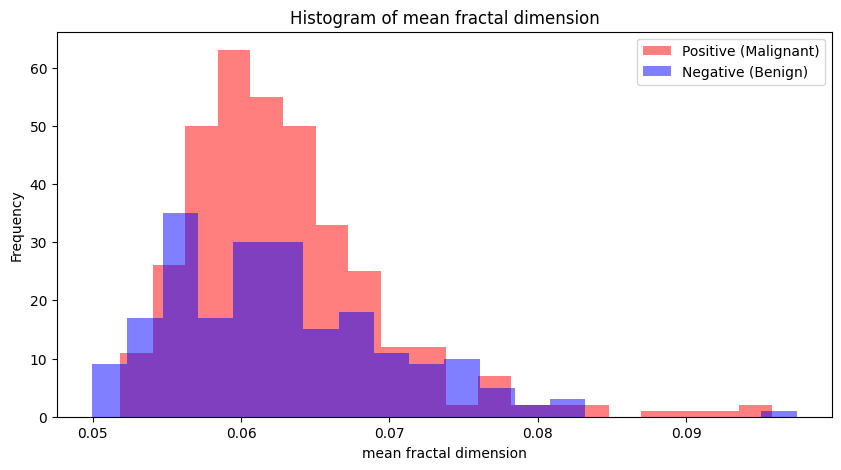

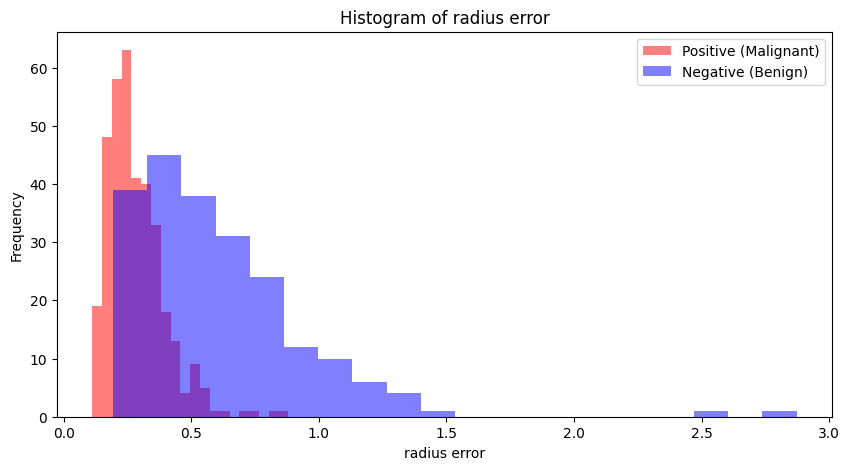

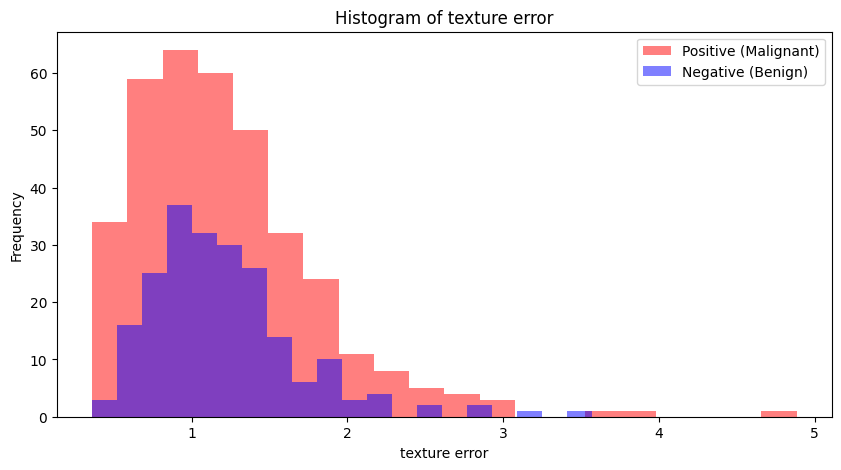

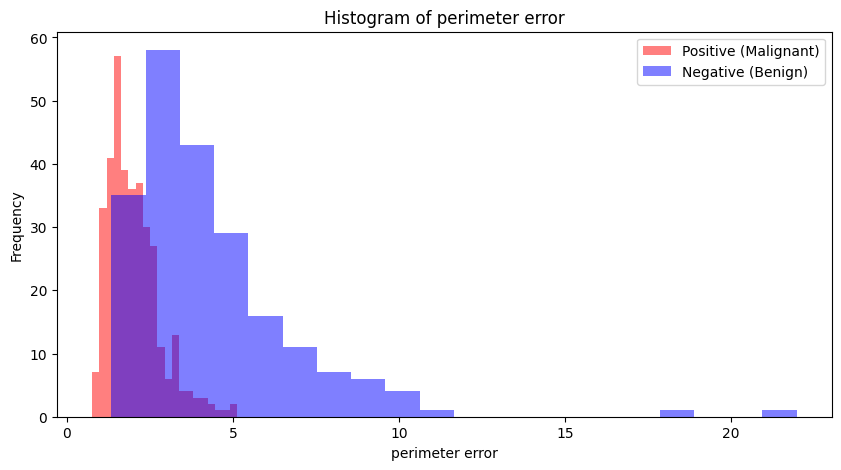

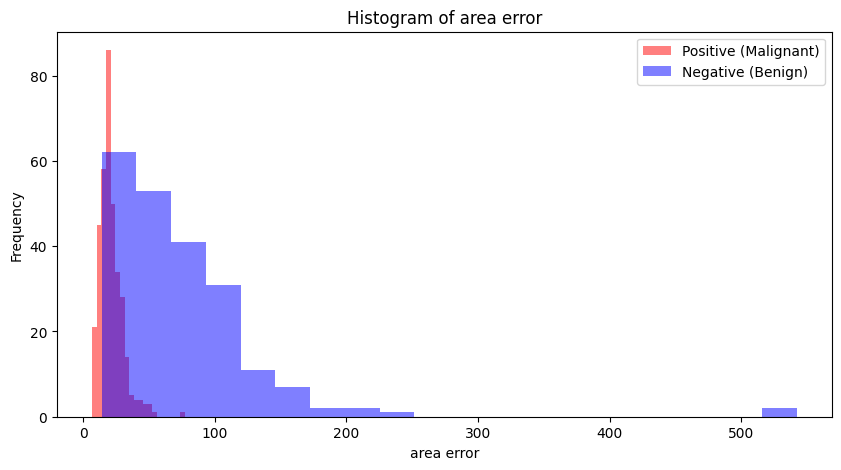

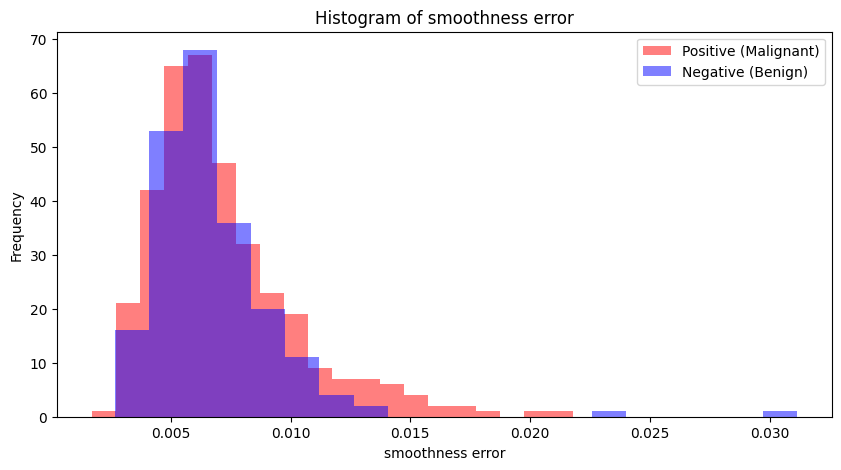

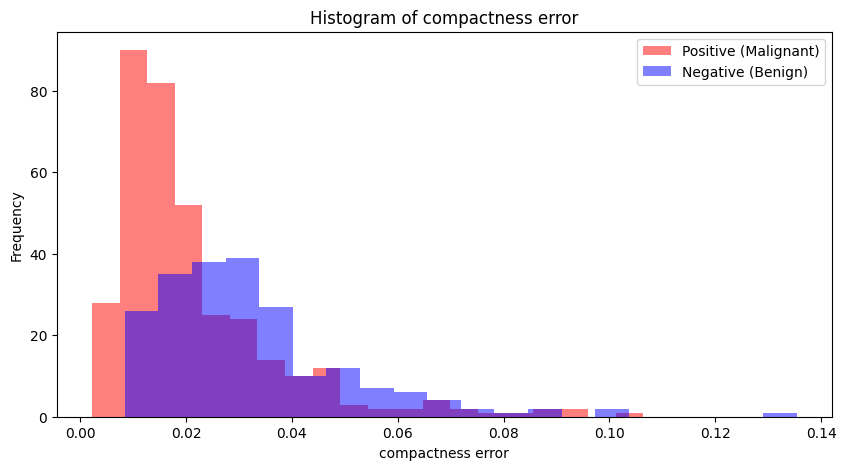

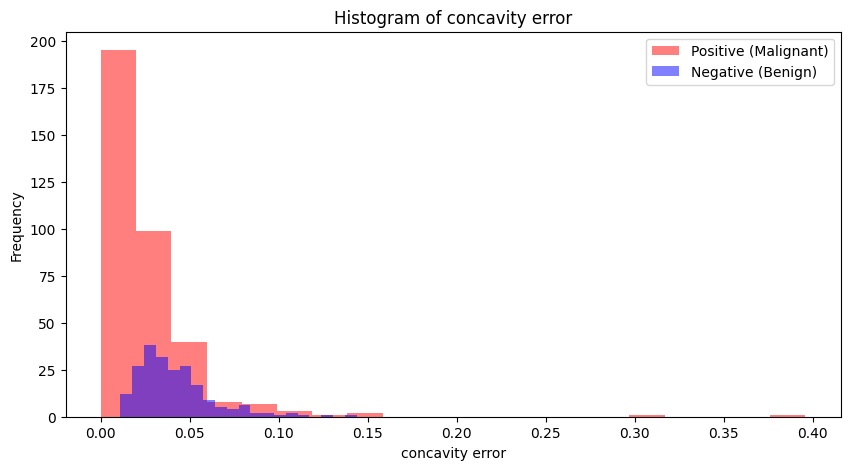

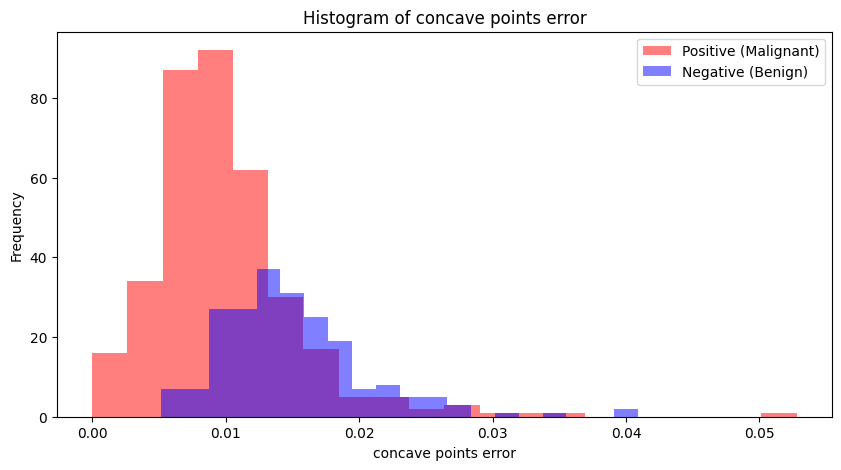

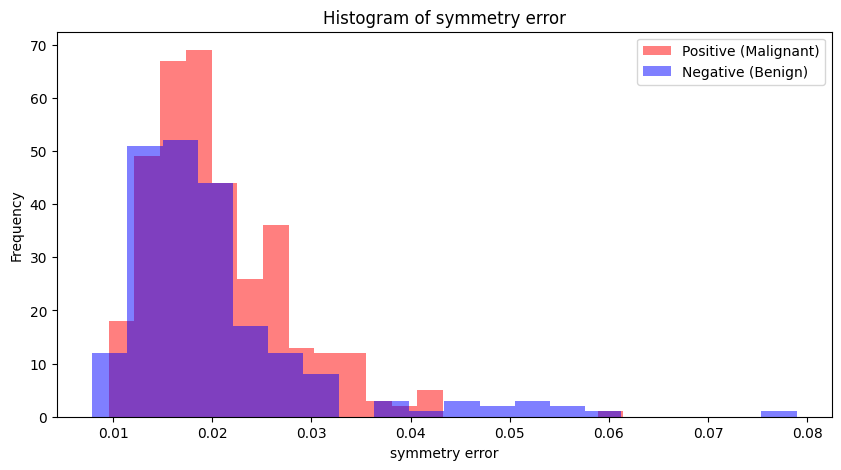

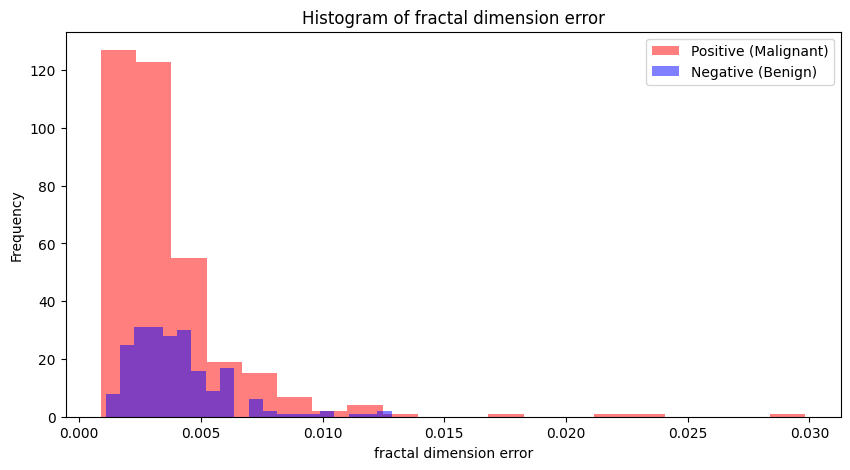

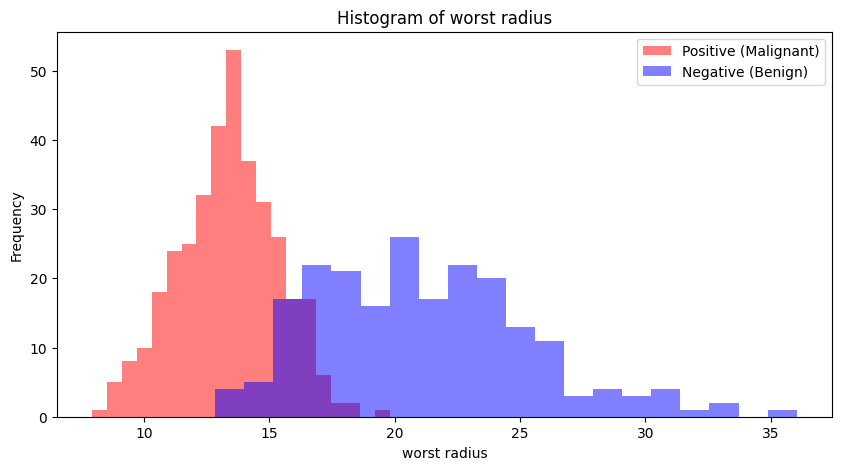

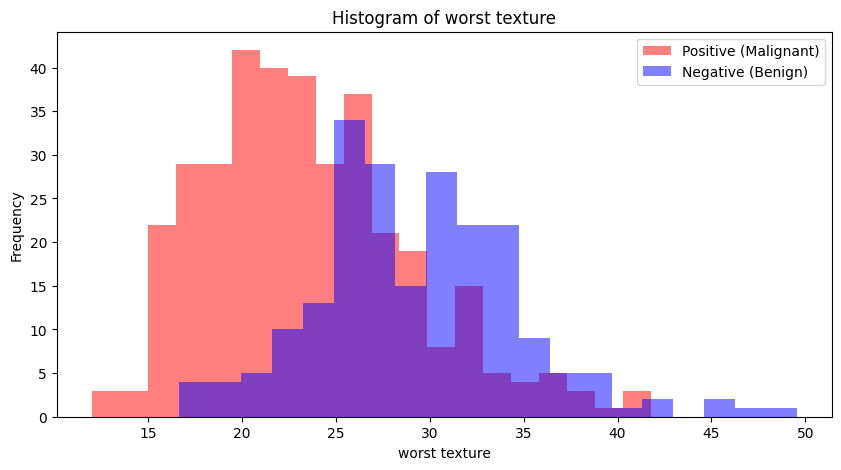

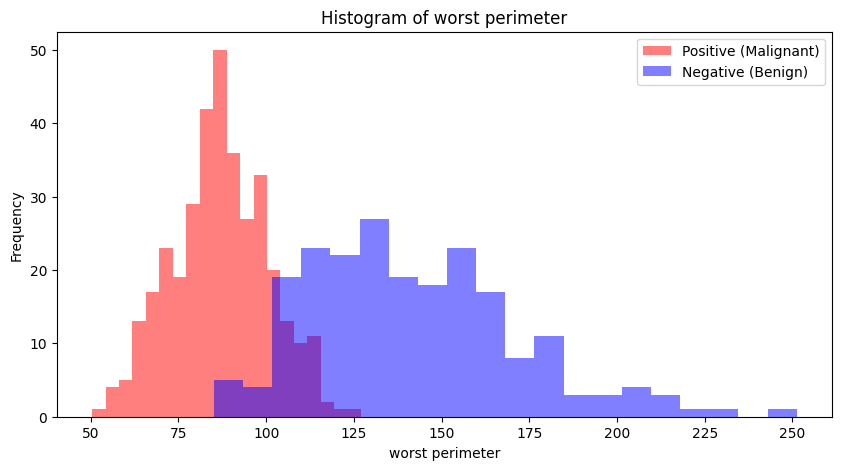

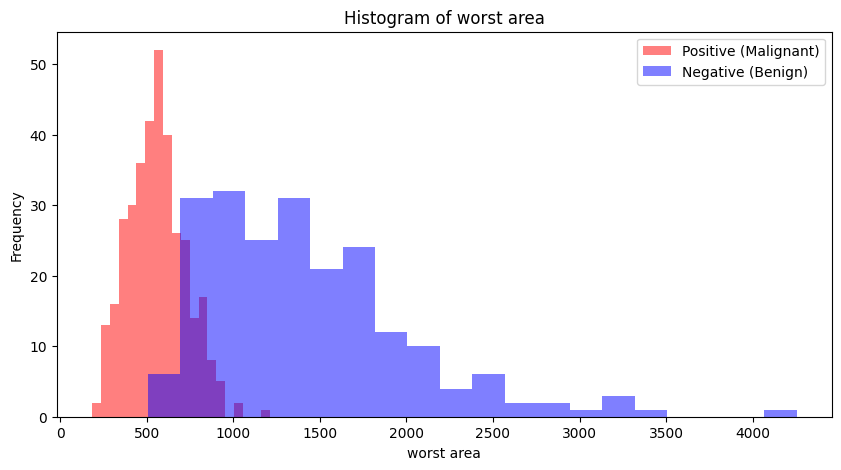

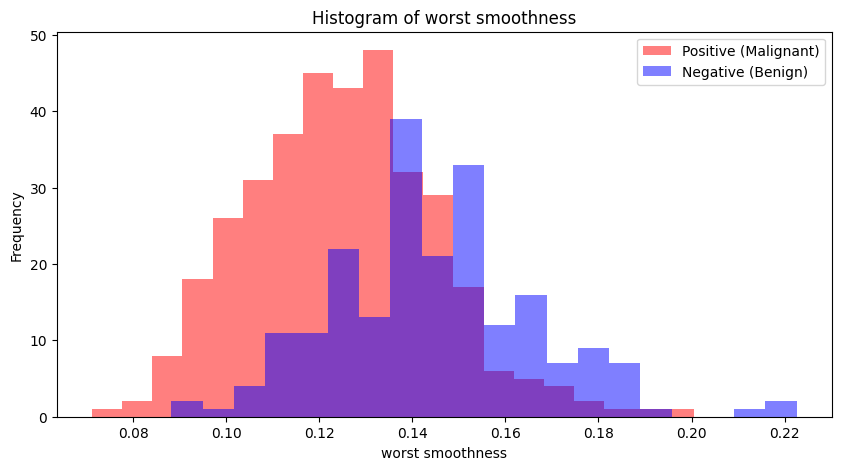

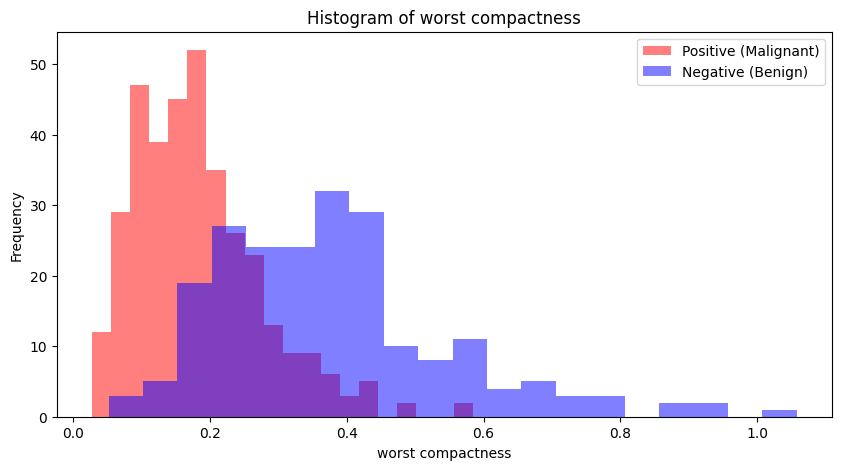

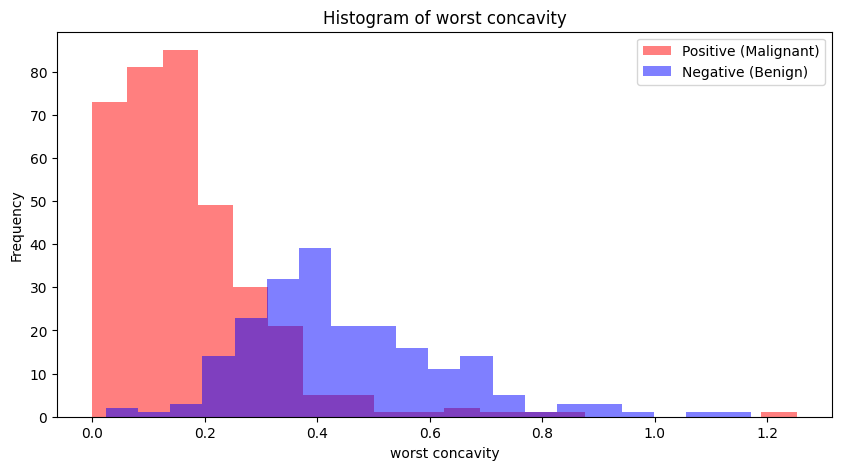

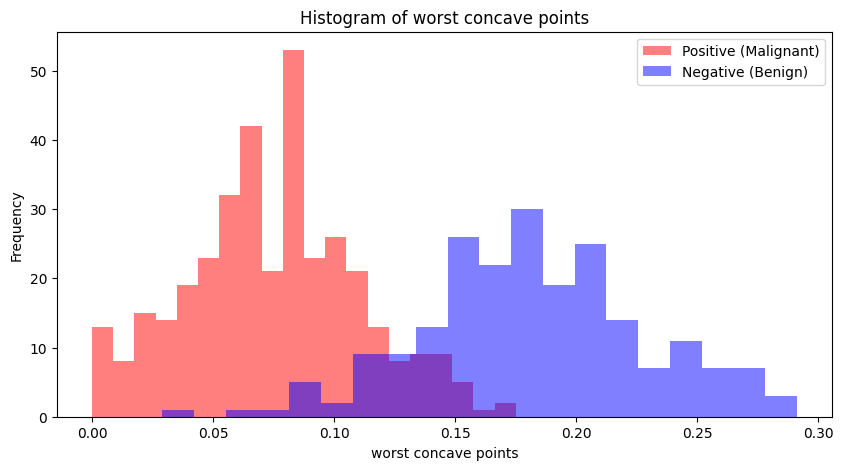

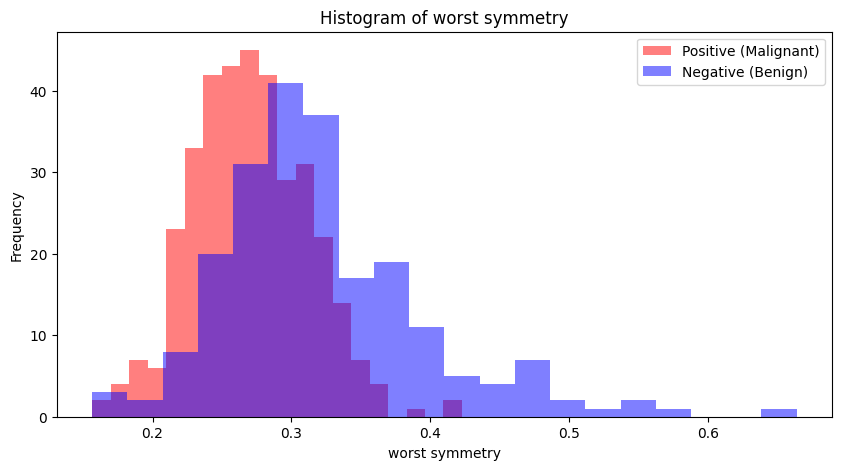

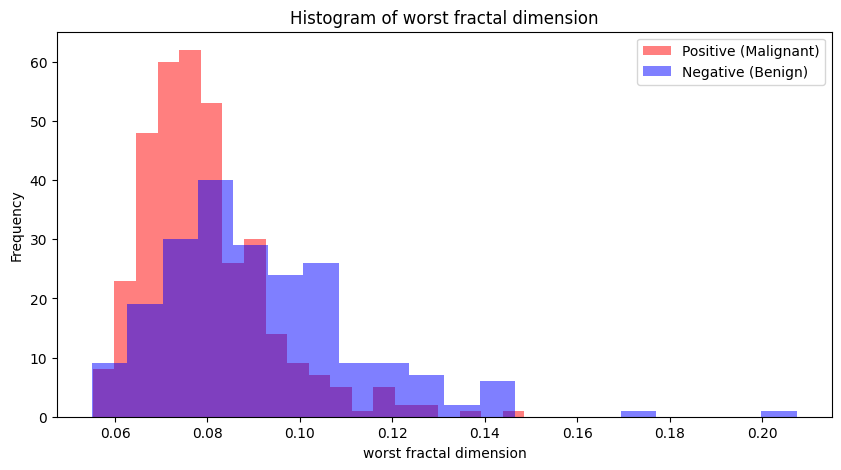

In [8]:
features = df_features.columns
for feature in features:
    plt.figure(figsize=(10, 5))
    plt.hist(df_positive[feature], bins=20, alpha=0.5, label='Positive (Malignant)', color='red')
    plt.hist(df_negative[feature], bins=20, alpha=0.5, label='Negative (Benign)', color='blue')
    plt.title(f'Histogram of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

Q8. Find Visualization of relationships between features and diagnoses.

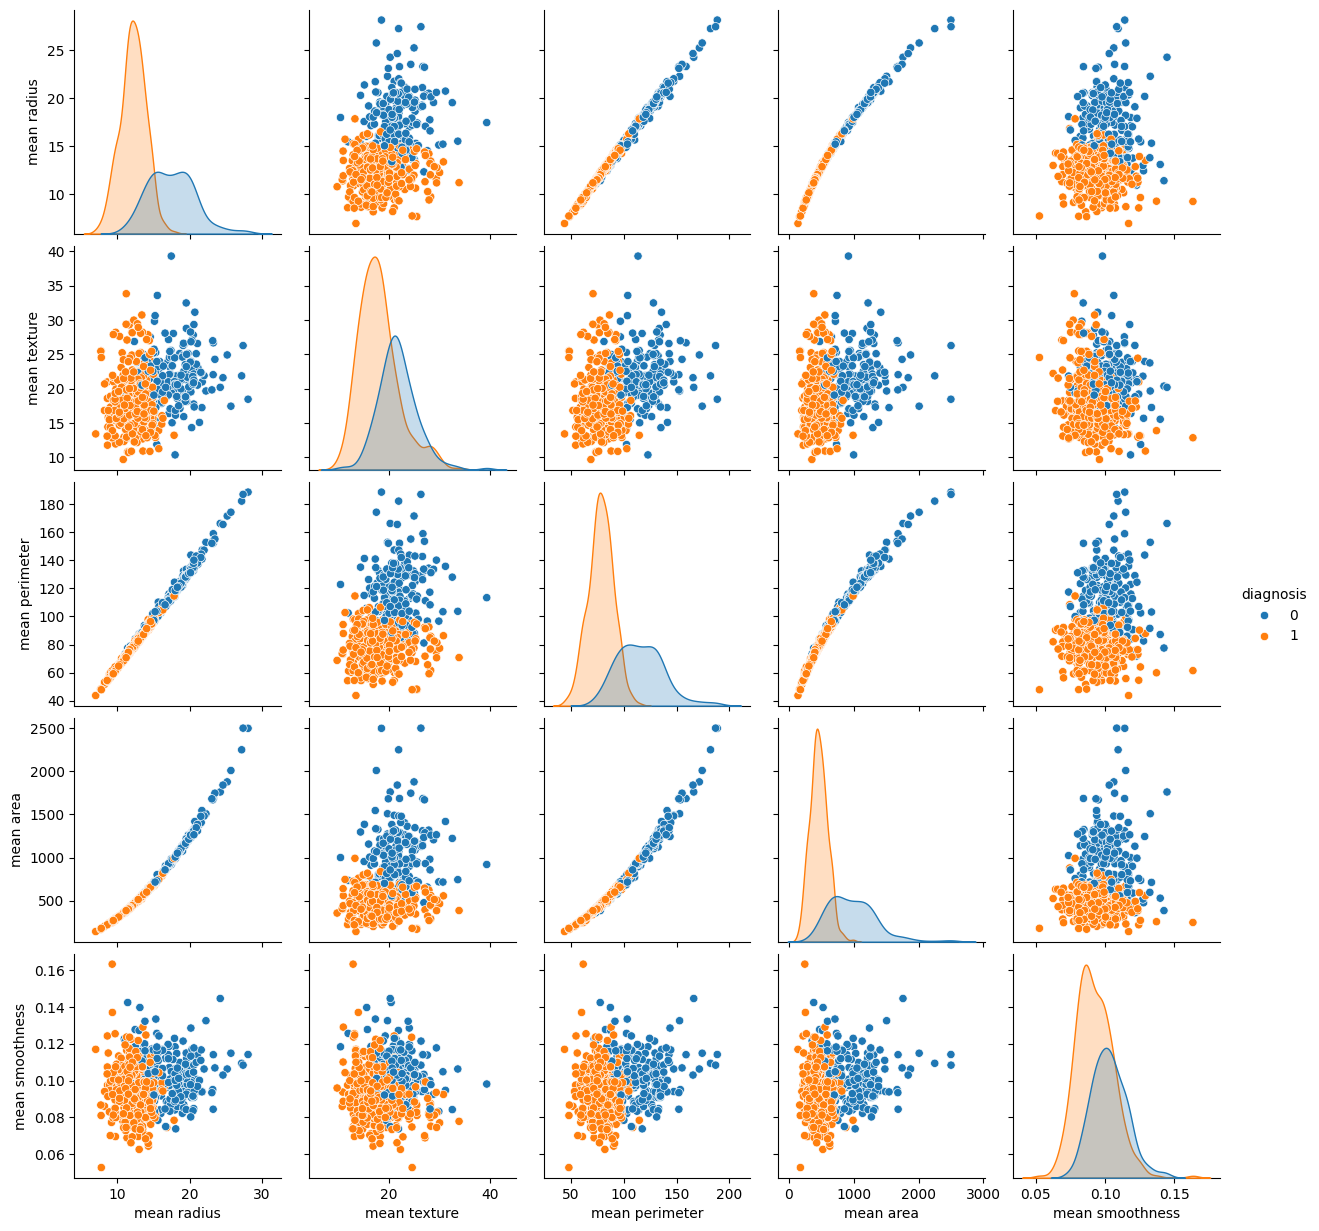

In [9]:
import seaborn as sns
sns.pairplot(df, hue='diagnosis', vars=features[:5])
plt.show()

Q9. Split data into testing and training set. Use 80% for training

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (455, 30)
Testing set shape: (114, 30)


Q10. normalize features to account for feature scaling

In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Q11. Apply DT, NB, KNN Logistic Regression and SVm to find accuracy, F1-Score and Recall.

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, recall_score
models = {
    'Decision Tree': DecisionTreeClassifier(),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Logistic Regression': LogisticRegression(max_iter=10000),
    'Support Vector Machine': SVC()
}
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred)
    }
for name, metrics in results.items():
    print(f"{name}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")

C:\Users\Asus\AppData\Local\Programs\Python\Python39\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Asus\AppData\Local\Programs\Python\Python39\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\Asus\AppData\Local\Programs\Python\Python39\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\Asus\AppData\Local\Programs\Python\Python39\lib\subprocess.py", line 951, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Asus\AppData\Local\Programs\Python\Python39\lib\subprocess.py"

Decision Tree:
  Accuracy: 0.9386
  F1 Score: 0.9504
  Recall: 0.9437
Naive Bayes:
  Accuracy: 0.9649
  F1 Score: 0.9722
  Recall: 0.9859
K-Nearest Neighbors:
  Accuracy: 0.9474
  F1 Score: 0.9577
  Recall: 0.9577
Logistic Regression:
  Accuracy: 0.9737
  F1 Score: 0.9790
  Recall: 0.9859
Support Vector Machine:
  Accuracy: 0.9825
  F1 Score: 0.9861
  Recall: 1.0000


Q12. Further apply the PCA to do the same exercise in Q11.


In [ ]:
Q13. Do the Comprative study with PCA and WITHout PCA.